# GD & SGD 비교

GD: 1733152358.447927 ~ 1733152358.5018563 : 0.05392932891845703
SGD: 1733152358.50221 ~ 1733152359.384769 : 0.882559061050415


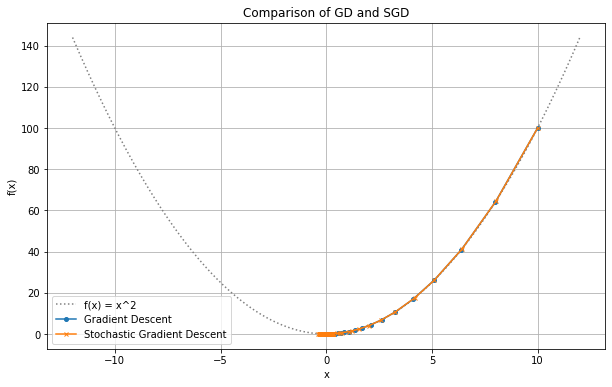

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import time

# 함수 정의
def function(x):
    return x**2

# 함수의 기울기
def gradient(x):
    return 2 * x

# Gradient Descent 구현
def gradient_descent(initial_x, learning_rate, iterations):
    start = time.time()
    x = initial_x
    history = [x]
    for _ in range(iterations):
        grad = gradient(x)  # 전체 데이터에 대한 기울기 계산
        x -= learning_rate * grad  # 파라미터 업데이트
        history.append(x)
    end = time.time()
    return history, start, end

# Stochastic Gradient Descent 구현
def stochastic_gradient_descent(initial_x, learning_rate, iterations):
    start = time.time()
    x = initial_x
    history = [x]
    for _ in range(iterations):
        grad = gradient(x)  # SGD에서도 동일한 함수의 기울기를 사용 (단순 샘플 기반 예제)
        noise = np.random.normal(0, 0.5)  # SGD의 샘플링에 따른 노이즈 추가
        x -= learning_rate * (grad + noise)  # 파라미터 업데이트
        history.append(x)
    end = time.time()
    return history, start, end

# 초기값 및 학습률 설정
initial_x = 10  # 시작점
learning_rate = 0.1
iterations = 50000

# 두 방법 실행
gd_history,s1,e1 = gradient_descent(initial_x, learning_rate, iterations)
sgd_history,s2,e2 = stochastic_gradient_descent(initial_x, learning_rate, iterations)

print(f"GD: {s1} ~ {e1} : {e1-s1}")
print(f"SGD: {s2} ~ {e2} : {e2-s2}")
# 결과 시각화
x_vals = np.linspace(-12, 12, 400)
y_vals = function(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label='f(x) = x^2', color='gray', linestyle='dotted')
plt.plot(gd_history, [function(x) for x in gd_history], 'o-', label='Gradient Descent', markersize=4)
plt.plot(sgd_history, [function(x) for x in sgd_history], 'x-', label='Stochastic Gradient Descent', markersize=4)
plt.title('Comparison of GD and SGD')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid()
plt.show()


GD: 1733154187.041939 ~ 1733154187.0903118 : 0.048372745513916016
SGD: 1733154187.0906022 ~ 1733154187.0919833 : 0.0013811588287353516


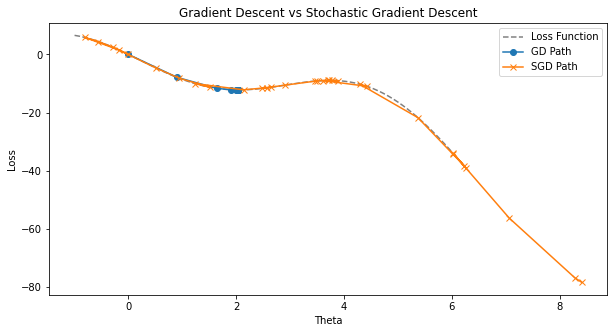

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import time

# 손실 함수 예제: J(θ) = (θ - 3)^2
# def loss_function(theta):
#     return (theta - 3)**2

# # 기울기 계산 (편미분)
# def compute_gradient(theta):
#     return 2 * (theta - 3)
# 손실 함수 및 기울기
def loss_function(theta):
    return -9*np.sin(theta) -theta**2
    return np.sin(theta) + theta**2 #(theta - 3)**2

def compute_gradient(theta):
    return -9*np.cos(theta) -2*theta
    return np.cos(theta) + 2*theta#2 * (theta - 3)

# Gradient Descent 구현
def gradient_descent(initial_theta, learning_rate, steps, data):
    start = time.time()
    theta = initial_theta
    history = [theta]
    for _ in range(steps):
        gradient = np.mean([compute_gradient(theta) for x in data])  # 전체 데이터셋 사용
        theta -= learning_rate * gradient
        history.append(theta)
    end = time.time()
    return history, start, end

# Stochastic Gradient Descent 구현
def stochastic_gradient_descent(initial_theta, learning_rate, steps, data):
    start = time.time()
    theta = initial_theta
    history = [theta]
    for _ in range(steps):
        x = np.random.choice(data)  # 랜덤 샘플 선택
        gradient = compute_gradient(x)  # 선택된 샘플로 기울기 계산
        theta -= learning_rate * gradient
        history.append(theta)
    end = time.time()
    return history, start, end

# 데이터셋 (단순한 예제에서는 데이터 크기만 중요)
data = np.linspace(1, 5, 100)  # 가상의 데이터

# 초기값 및 학습 설정
initial_theta = 0
learning_rate = 0.1
steps = 30

# GD와 SGD 학습
gd_history,s1,e1 = gradient_descent(initial_theta, learning_rate, steps, data)
sgd_history,s2,e2 = stochastic_gradient_descent(initial_theta, learning_rate, steps, data)

print(f"GD: {s1} ~ {e1} : {e1-s1}")
print(f"SGD: {s2} ~ {e2} : {e2-s2}")

# 시각화
plt.figure(figsize=(10, 5))

# 손실 함수 그래프
thetas = np.linspace(-1, 6, 1000)
losses = [loss_function(theta) for theta in thetas]
plt.plot(thetas, losses, label="Loss Function", color="gray", linestyle="--")

# GD 경로
plt.plot(gd_history, [loss_function(theta) for theta in gd_history], label="GD Path", marker="o")

# SGD 경로
plt.plot(sgd_history, [loss_function(theta) for theta in sgd_history], label="SGD Path", marker="x")

# 그래프 꾸미기
plt.title("Gradient Descent vs Stochastic Gradient Descent")
plt.xlabel("Theta")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [ ]:
Local Minimum에서 빠져나오는 모습

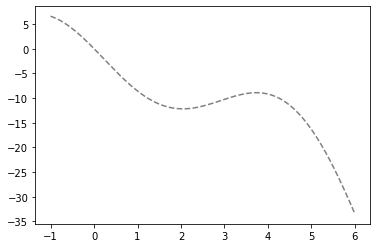

In [78]:
thetas = np.linspace(-1, 6, 1000)
def loss_function(theta):
    return -9*np.sin(theta) -theta**2
losses = [loss_function(theta) for theta in thetas]
plt.plot(thetas, losses, label="Loss Function", color="gray", linestyle="--")

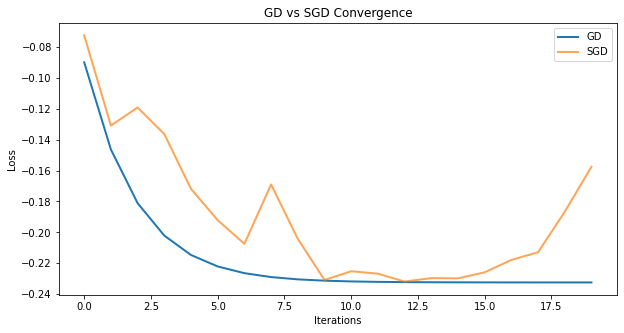

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# 손실 함수 및 기울기
def loss_function(theta):
    return np.sin(theta) + theta**2#(theta - 3)**2

def gradient(theta):
    return np.cos(theta) + 2*theta#2 * (theta - 3)

# GD와 SGD 구현
def gradient_descent(steps, learning_rate):
    theta = 0  # 초기값
    history = []
    for _ in range(steps):
        grad = gradient(theta)
        theta -= learning_rate * grad
        history.append(loss_function(theta))
    return history

def stochastic_gradient_descent(steps, learning_rate):
    theta = 0  # 초기값
    history = []
    for _ in range(steps):
        grad = gradient(theta) + np.random.normal(0, 0.5)  # 노이즈 추가
        theta -= learning_rate * grad
        history.append(loss_function(theta))
    return history

# 학습 비교
steps = 20
learning_rate = 0.1
gd_history = gradient_descent(steps, learning_rate)
sgd_history = stochastic_gradient_descent(steps, learning_rate)

# 시각화
plt.figure(figsize=(10, 5))
plt.plot(gd_history, label="GD", linewidth=2)
plt.plot(sgd_history, label="SGD", linewidth=2, alpha=0.7)
plt.title("GD vs SGD Convergence")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()


# ADAM

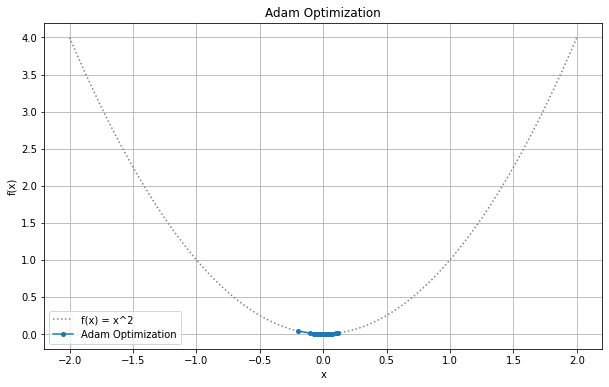

In [3]:
import numpy as np

# Adam Optimizer 구현
def adam_optimizer(gradients, lr=0.01, beta1=0.9, beta2=0.999, epsilon=1e-8, epochs=100):
    m, v = 0, 0  # 1차, 2차 모멘트 초기화
    t = 0  # 시간 초기화
    x = np.random.randn()  # 초기 파라미터 값
    
    history = [x]
    for _ in range(epochs):
        t += 1
        g = gradients(x)  # 현재 기울기 계산
        
        # 1차, 2차 모멘트 업데이트
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * (g**2)
        
        # Bias Correction
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        
        # 파라미터 업데이트
        x -= lr * m_hat / (np.sqrt(v_hat) + epsilon)
        history.append(x)
    
    return history

# 예제: f(x) = x^2 최소화
def gradients(x):
    return 2 * x

# Adam 최적화 실행
lr = 0.1
epochs = 100
history = adam_optimizer(gradients, lr=lr, epochs=epochs)

# 결과 시각화
import matplotlib.pyplot as plt

x_vals = np.linspace(-2, 2, 400)
y_vals = x_vals**2

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label='f(x) = x^2', color='gray', linestyle='dotted')
plt.plot(history, [x**2 for x in history], 'o-', label='Adam Optimization', markersize=4)
plt.title('Adam Optimization')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid()
plt.show()


# 편미분

In [4]:
import numpy as np

# 손실 함수 예제: J(θ) = (θ1 - 2)^2 + (θ2 + 3)^2
def loss_function(theta):
    return (theta[0] - 2)**2 + (theta[1] + 3)**2

# 기울기(편미분) 계산
def compute_gradient(theta):
    d_theta1 = 2 * (theta[0] - 2)  # ∂J/∂θ1
    d_theta2 = 2 * (theta[1] + 3)  # ∂J/∂θ2
    return np.array([d_theta1, d_theta2])

# Gradient Descent 구현
def gradient_descent(initial_theta, learning_rate, steps):
    theta = np.array(initial_theta, dtype=float)
    for step in range(steps):
        gradient = compute_gradient(theta)
        theta -= learning_rate * gradient  # 각 파라미터 독립적으로 업데이트
        print(f"Step {step + 1}: θ = {theta}, Loss = {loss_function(theta)}")
    return theta

# 초기값 및 학습
initial_theta = [0, 0]  # 초기 θ1, θ2 값
learning_rate = 0.1
steps = 10

optimal_theta = gradient_descent(initial_theta, learning_rate, steps)
print(f"Optimal θ: {optimal_theta}")


Step 1: θ = [ 0.4 -0.6], Loss = 8.32
Step 2: θ = [ 0.72 -1.08], Loss = 5.3248
Step 3: θ = [ 0.976 -1.464], Loss = 3.4078720000000002
Step 4: θ = [ 1.1808 -1.7712], Loss = 2.18103808
Step 5: θ = [ 1.34464 -2.01696], Loss = 1.3958643711999998
Step 6: θ = [ 1.475712 -2.213568], Loss = 0.893353197568
Step 7: θ = [ 1.5805696 -2.3708544], Loss = 0.5717460464435202
Step 8: θ = [ 1.66445568 -2.49668352], Loss = 0.3659174697238528
Step 9: θ = [ 1.73156454 -2.59734682], Loss = 0.23418718062326582
Step 10: θ = [ 1.78525164 -2.67787745], Loss = 0.14987979559889023
Optimal θ: [ 1.78525164 -2.67787745]
